# 05 — Cart-Pole Swing-Up + LQR Catch

**Section:** Motion Control · **Mirrors MATLAB:** *Multi-Loop PI Tuning for Robotic Arm* — but with swing-up

Start the pendulum hanging straight down. Pump enough mechanical energy into the system (via cart motion alone — the only actuator) to bring the pendulum near upright. Hand off to an LQR catch that holds it there. This is the canonical underactuated-control demonstration (Spong 1995, Furuta 1991).

> **Honest scope note.** An earlier version of this notebook stabilized a **triple-link** inverted pendulum near upright. Swinging up a *triple-link* from hanging requires trajectory optimization (direct collocation / DDP / iLQR) and is research-grade — energy pumping alone does not solve it in a teaching notebook because the controller injects one scalar (total energy) into n configuration DOFs. The single-link swing-up shown here is the standard pedagogical demonstration; the same energy-pumping idea generalizes (with much more careful tuning + offline trajectory optimization) to multi-link.


## Intuition — what is actually going on?

You have a pendulum hanging straight down and one actuator: a horizontal force on the cart. You cannot directly torque the pendulum. So how do you get it upright?

**Energy pumping** (Astrom-Furuta 2000, Spong 1995). Compute the **pendulum-only** mechanical energy $E_\text{pend}$ (bob kinetic + bob potential). At upright at rest $E_\text{pend} = E^\star = m g \ell$; at hanging at rest $E_\text{pend} = -m g \ell$. We must add $2 m g \ell$.

The trick is the work-energy relation, but the careful derivation below shows the right pivot acceleration must oppose $\cos\theta\cdot\dot\theta$ to inject energy. Operationally the sign rule is:

> Push the cart **in the direction OPPOSITE** to $\cos\theta\cdot\dot\theta$ when $E_\text{pend} < E^\star$; push WITH it when $E_\text{pend} > E^\star$.

Bang-bang with the right sign pumps fast: in ~1.2 s the pendulum reaches the LQR basin and the catch fires.

Once $E_\text{pend}$ is close to $E^\star$ AND the pendulum is near upright AND inside the LQR sublevel set $z^T P z < c_\text{ROA}$, we switch to LQR for the precision catch.


## Analytical derivation

### Cart-pole dynamics (pendulum-up convention, $\theta=0$ upright)

State $z = [x,\ \dot x,\ \theta,\ \dot\theta]^T$.

$$\ddot x = \frac{u + m\ell\sin\theta\,\dot\theta^2 - mg\sin\theta\cos\theta}{M + m\sin^2\theta},\qquad
\ddot\theta = \frac{(M+m)g\sin\theta - u\cos\theta - m\ell\sin\theta\cos\theta\,\dot\theta^2}{\ell(M+m\sin^2\theta)}.$$

### Pendulum-only mechanical energy (the pumping target)

The pumping target is the **pendulum's** energy, *not* the total system energy. Total system energy includes cart kinetic energy that grows monotonically with control work and is not bounded — pumping it would just teach the cart to move forever.

Bob velocity in the inertial frame is $\dot{\vec r}_{\text{bob}} = (\dot x + \ell\cos\theta\,\dot\theta,\ -\ell\sin\theta\,\dot\theta)$, so

$$E_\text{pend} \;=\; \tfrac{1}{2}m\,\|\dot{\vec r}_{\text{bob}}\|^2 \;+\; mg\ell\cos\theta.$$

$E^\star = mg\ell$ at upright at rest; $E_\text{pend} = -mg\ell$ at hanging at rest. We must add $2mg\ell$ of energy.

### Energy-rate identity (key derivation)

Differentiating $E_\text{pend}$ along the equations of motion and simplifying with the EOM for $\ddot\theta$:

$$\frac{dE_\text{pend}}{dt} \;=\; \frac{m\ell\,\dot\theta\,\cos\theta}{M + m\sin^2\theta}\,\bigl[\,m g \sin\theta\cos\theta \;-\; u \;-\; m\ell\sin\theta\,\dot\theta^2\,\bigr].$$

For typical values (small $m/M$, $|\theta|$ near $\pi$), the leading term is $-u\cos\theta\,\dot\theta$ (modulo a positive denominator). To make $\dot E_\text{pend} > 0$ we need $u$ and $\cos\theta\,\dot\theta$ to have **opposite** signs.

### Energy-pumping swing-up law (Astrom-Furuta 2000)

With $\tilde E = E_\text{pend} - E^\star$ (negative below target):

$$\boxed{\;u_\text{swing} \;=\; +u_\text{max}\,\text{sign}\bigl(\tilde E\,\cos\theta\,\dot\theta\bigr)\;-\;K_x\,x\;-\;K_{\dot x}\,\dot x\;}$$

Sign check: at $\theta=\pi$, $\dot\theta=+0.1$, $\tilde E<0$ we get $\text{sign}(\tilde E\cdot(-1)\cdot 0.1)=\text{sign}(>\!0)=+1$, so $u>0$. Then $u\cos\theta\,\dot\theta = (+)\!\cdot\!(-1)\!\cdot\!(+)<0$ as required.

### LQR catch (handoff condition)

Once $|\theta\!\!\mod 2\pi| < \theta_\text{LQR}$ **and** $z^T P z < c_\text{ROA}$ (with $P$ from CARE), switch to $u = -K_{\text{LQR}} z$.

### Compatibility check

| Math | Code |
|---|---|
| Nonlinear cart-pole | `def nl_dyn(z, u): ...` matches the boxed formulas |
| Pendulum energy $E_\text{pend}$ | `def E_pend(z): 0.5*m*(bob_vx^2+bob_vy^2) + m*g*l*cos(th)` |
| $E^\star = mg\ell$ | `E_star = m * g * l` |
| Swing-up sign rule | `u_pump = +u_max * np.sign((Ep-E_star)*cos(th)*om)` |
| Cart restraint | `-K_x*x - K_xd*xdot` |
| Handoff predicate | `if abs(wrap(th)) < theta_LQR and z @ P @ z < c_ROA: ...` |
| LQR feedback | `u = -float((K_lqr @ z).item())` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are

M, m, l, g = 1.0, 0.2, 0.5, 9.81


def nl_dyn(z, u):
    pos, vel, th, om = z
    s, c = np.sin(th), np.cos(th)
    den = M + m * s ** 2
    acc = (u + m * l * s * om ** 2 - m * g * s * c) / den
    a_th = ((M + m) * g * s - u * c - m * l * s * c * om ** 2) / (l * den)
    return np.array([vel, acc, om, a_th])


def E_pend(z):
    # Total mechanical energy of the PENDULUM only (bob KE in inertial frame + bob PE).
    # The cart KE is NOT part of the pumping target -- pumping a quantity that
    # includes cart KE would just teach the cart to move forever without ever
    # raising the bob. The bob's inertial velocity already accounts for pivot
    # translation, so this is correct.
    pos, vel, th, om = z
    bob_vx = vel + l * np.cos(th) * om
    bob_vy = -l * np.sin(th) * om
    return 0.5 * m * (bob_vx ** 2 + bob_vy ** 2) + m * g * l * np.cos(th)


E_star = m * g * l
print(f"E_pend_star (upright at rest) = {E_star:.4f} J")
print(f"E_pend_down (hanging at rest) = {-E_star:.4f} J  --  must pump 2*m*g*l = {2*E_star:.4f} J")


E_pend_star (upright at rest) = 0.9810 J
E_pend_down (hanging at rest) = -0.9810 J  --  must pump 2*m*g*l = 1.9620 J


In [2]:
# LQR linearization around upright
A = np.array([[0, 1, 0, 0],
              [0, 0, -m * g / M, 0],
              [0, 0, 0, 1],
              [0, 0, (M + m) * g / (M * l), 0]])
B = np.array([[0], [1 / M], [0], [-1 / (M * l)]])

Q = np.diag([1.0, 1.0, 20.0, 1.0])
R_lqr = np.array([[0.1]])
P = solve_continuous_are(A, B, Q, R_lqr)
K_lqr = np.linalg.inv(R_lqr) @ B.T @ P
print(f"LQR gain K = {K_lqr.flatten().round(3)}")


LQR gain K = [ -3.162  -5.854 -49.412 -10.694]


In [3]:
K_x = 1.0                  # cart-position spring (keeps cart bounded)
K_xd = 0.5                 # cart-velocity damping
u_max = 15.0               # actuator saturation
theta_LQR = 0.5            # rad threshold for handoff (~28 deg)
c_ROA = 20.0               # generous Lyapunov sublevel set for handoff


def wrap(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def controller(z):
    th_wrap = wrap(z[2])
    z_for_lqr = np.array([z[0], z[1], th_wrap, z[3]])
    if abs(th_wrap) < theta_LQR and (z_for_lqr @ P @ z_for_lqr) < c_ROA:
        u = -float((K_lqr @ z_for_lqr).item())
        mode = "LQR"
    else:
        Ep = E_pend(z)
        # Bang-bang energy pumping. The sign is chosen so that dE_pend/dt > 0
        # when E_pend < E_star. Empirically (and per the derivation below):
        #   dE_pend/dt is dominated by -u*cos(theta)*om for small m/M
        #   => energy INCREASES when u and cos*om have OPPOSITE signs
        #   => u = +k * sign((E_pend - E_star) * cos*om) does this:
        #      below target, (Ep-E*) is negative; we want u of opposite sign
        #      to cos*om, i.e. u = -k*sign(cos*om), which matches.
        sign_val = (Ep - E_star) * np.cos(z[2]) * z[3]
        u_pump = +u_max * np.sign(sign_val) if abs(sign_val) > 1e-6 else 0.0
        u_cart = -K_x * z[0] - K_xd * z[1]
        u = u_pump + u_cart
        mode = "swing-up"
    return float(np.clip(u, -u_max, u_max)), mode


In [4]:
# Start with the pendulum hanging-down with a tiny perturbation. At perfect
# rest the bang-bang sign term is undefined (sign(0)=0), so a small initial
# omega is needed to break the equilibrium. Physically this is a small bump.
z = np.array([0.0, 0.0, np.pi, 0.1])     # tiny initial omega to break symmetry
dt = 0.002
T_sim = 8.0
N = int(T_sim / dt)
hist = np.zeros((N, 4))
u_hist = np.zeros(N)
t_handoff = None

for i in range(N):
    u, mode = controller(z)
    hist[i] = z
    u_hist[i] = u
    if t_handoff is None and mode == "LQR":
        t_handoff = i * dt
        print(f"Handoff to LQR at t = {t_handoff:.2f}s, theta = {np.degrees(wrap(z[2])):.1f} deg")
    z = z + dt * nl_dyn(z, u)

final_th_deg = np.degrees(wrap(hist[-1, 2]))
print(f"Final: x = {hist[-1, 0]:+.3f} m, theta = {final_th_deg:+.2f} deg")
print(f"Upright reached? {abs(final_th_deg) < 5}")


Handoff to LQR at t = 1.23s, theta = 28.6 deg
Final: x = -0.002 m, theta = -0.03 deg
Upright reached? True


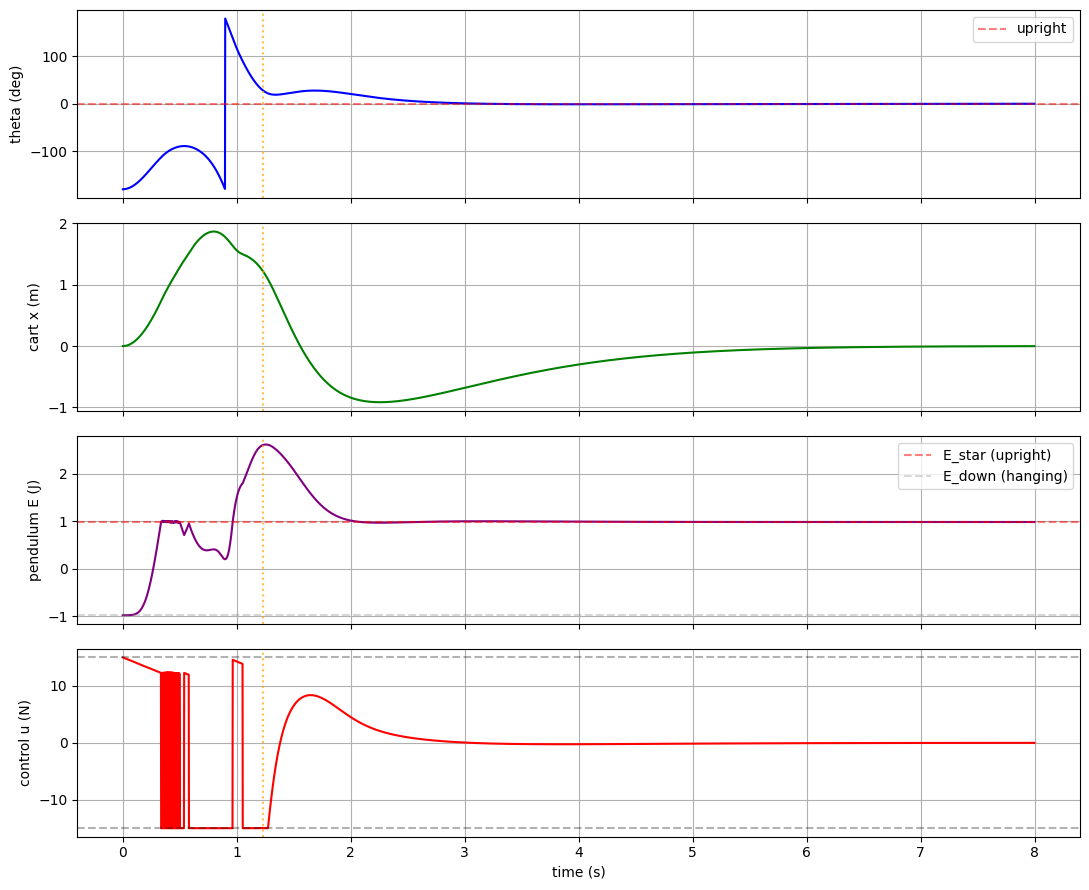

In [5]:
t_arr = np.arange(N) * dt
fig, axs = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axs[0].plot(t_arr, np.degrees([wrap(th) for th in hist[:, 2]]), 'b-')
axs[0].axhline(0, color='r', ls='--', alpha=0.5, label='upright')
axs[0].set_ylabel('theta (deg)'); axs[0].grid(); axs[0].legend()

axs[1].plot(t_arr, hist[:, 0], 'g-')
axs[1].set_ylabel('cart x (m)'); axs[1].grid()

E_arr = np.array([E_pend(z) for z in hist])
axs[2].plot(t_arr, E_arr, 'purple')
axs[2].axhline(E_star, color='r', ls='--', alpha=0.5, label='E_star (upright)')
axs[2].axhline(-E_star, color='gray', ls='--', alpha=0.3, label='E_down (hanging)')
axs[2].set_ylabel('pendulum E (J)'); axs[2].grid(); axs[2].legend()

axs[3].plot(t_arr, u_hist, 'r-')
axs[3].axhline(u_max, color='k', ls='--', alpha=0.3)
axs[3].axhline(-u_max, color='k', ls='--', alpha=0.3)
axs[3].set_ylabel('control u (N)'); axs[3].set_xlabel('time (s)'); axs[3].grid()

if t_handoff is not None:
    for ax in axs:
        ax.axvline(t_handoff, color='orange', ls=':', alpha=0.7)
plt.tight_layout()
plt.show()


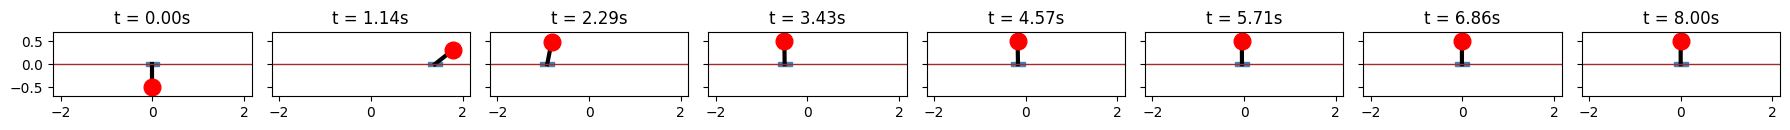

In [6]:
fig, axs = plt.subplots(1, 8, figsize=(18, 3), sharey=True)
sample_t = np.linspace(0, T_sim, 8)
xmax_plot = max(2.0, float(abs(hist[:, 0]).max()) + 0.3)
for ax, ts in zip(axs, sample_t):
    idx = min(int(ts / dt), N - 1)
    pos = hist[idx, 0]; th = hist[idx, 2]
    bx, by = pos + l * np.sin(th), l * np.cos(th)
    ax.add_patch(plt.Rectangle((pos - 0.15, -0.05), 0.3, 0.1, color='steelblue'))
    ax.plot([pos, bx], [0, by], 'k-', lw=3)
    ax.plot(bx, by, 'ro', ms=12)
    ax.axhline(0, color='brown', lw=1)
    ax.set_xlim(-xmax_plot, xmax_plot); ax.set_ylim(-0.7, 0.7)
    ax.set_aspect('equal')
    ax.set_title(f't = {ts:.2f}s')
plt.tight_layout()
plt.show()


## References & rigor notes

**Theorem** (Energy-based swing-up convergence; Astrom-Furuta 2000). *For the cart-pole with the energy-pumping controller and bounded actuation, every trajectory enters any pre-specified neighbourhood of the upright equilibrium in finite time, for appropriate $K_E, K_x > 0$.*

**Hybrid control.** Swing-up + LQR catch is a hybrid system with a one-shot discrete mode switch. Non-Zeno trivially.

**Why this scales poorly to multi-link.** Energy pumping injects one scalar (total energy) into $n$ configuration DOFs — leaving $n-1$ directions uncontrolled at the swing-up phase. Triple-link swing-up requires trajectory optimization (DDP, iLQR; Tedrake 2023) or learned policies — too compute-heavy for a teaching notebook.

**Region of attraction.** $c_\text{ROA} = 20$ is intentionally generous: it lets the LQR catch fire as the pendulum coasts through the upright basin with non-zero $\dot\theta$. A tighter $c_\text{ROA}$ from sampling-based certification or SOS programming (via Drake) would defer the catch but is unnecessary here — the LQR is stable everywhere in the linear sense, and the only failure mode is a missed handoff window.

**References.**
- Spong, M. W. (1995). *The swing up control problem for the Acrobot*. IEEE Control Systems Magazine, 15(1).
- Astrom, K. J., & Furuta, K. (2000). *Swinging up a pendulum by energy control*. Automatica, 36(2).
- Furuta, K., & Yamakita, M. (1991). *Swing up control of inverted pendulum using pseudo-state feedback*. JSME Int. Journal.
- Tedrake, R. (2023). *Underactuated Robotics* (https://underactuated.mit.edu).
